# H-PPO 主训练入口

该笔记本将逐步整合环境、算法与配置，完成 torchrl + gymnasium 的 H-PPO 训练流程。

In [1]:
# 在 Jupyter 环境中重复运行时，先完全重置 logger 状态
# 这样可以避免重复添加 handler 导致日志输出多次
import sys
sys.path.insert(0, '.')  # 确保能导入本地模块

from algo.logger import reset_logger
reset_logger()  # 清理所有旧的 handler 和状态

In [2]:
from dataclasses import replace
from pathlib import Path
from typing import Dict
from copy import deepcopy
import math
import torch
import yaml
import os
import numpy as np
import pandas as pd
from collections import OrderedDict
import importlib
from matplotlib import pyplot as plt

from algo import HPPOConfig, build_hppo_modules, train_hppo
from algo.logger import get_logger, setup_logger
from env import (
    MACSimulatorConfig,
    SatelliteMACEnv,
    SatelliteMACEnvConfig,
    default_simulator_config,
    build_gym_env,
)
from torchrl.envs import ParallelEnv, SerialEnv, TransformedEnv
from torchrl.envs.libs.gym import GymWrapper
from torchrl.envs.transforms import Compose, DoubleToFloat
import matplotlib.font_manager as font_manager
import scienceplots
plt.style.use(['science', 'no-latex'])
plt.rcParams['font.family'] = ['sans-serif']
plt.rcParams['font.sans-serif'] = ['Noto Sans SC',]
import algo.hppo
importlib.reload(algo.hppo)
from algo import train_hppo

# 导入评估工具函数
from utils.evaluate import evaluate_trained_agent, _scalar, load_yaml_config


In [ ]:
CONFIG_PATH = Path("conf/default.yaml")
raw_config = load_yaml_config(CONFIG_PATH)
seed = int(raw_config.get("seed", 20251202))
torch.manual_seed(seed)
log_section = raw_config.get("logging", {})
log_file = f"logs/{seed}_dynamic_training.log"
os.remove(log_file) if os.path.exists(log_file) else None

log_level = log_section.get("level", "INFO")
setup_logger(log_file, log_level)
my_logger = get_logger()
my_logger.info(f"Logger initialized (level={log_level}, file={log_file or '<stderr>'})")
env_section = dict(raw_config.get("environment", {}))
algo_section = raw_config.get("algorithm", {})
env_section.setdefault("noise_scale", 0.01)
if "motion_per_step" not in env_section:
    env_section["motion_per_step"] = default_simulator_config().motion_per_step


def _override_sim_config(overrides: Dict) -> MACSimulatorConfig:
    base_config = default_simulator_config()
    total = overrides.get("total_preambles")
    split = overrides.get("base_preamble_split")
    if total is not None:
        base_config = replace(base_config, total_preambles=int(total))
    if split is not None:
        if len(split) != 3:
            raise ValueError("base_preamble_split must contain three integers")
        base_config = replace(
            base_config,
            base_preamble_split=tuple(int(x) for x in split),
        )
    noise_scale = overrides.get("noise_scale")
    if noise_scale is not None:
        base_config = replace(base_config, noise_scale=float(noise_scale))
    motion_per_step = overrides.get("motion_per_step")
    if motion_per_step is not None:
        base_config = replace(base_config, motion_per_step=float(motion_per_step))
    # 配置历史长度 (Simulator 层的 history_size)
    # 注意: 由于 HISTORY_DIM 是硬编码的，当前必须保持为 10
    # 如果需要修改，需要同步更新 mac_simulator.py 中的限制
    history_size = overrides.get("history_size", 10)
    if history_size != 10:
        my_logger.warning(
            f"history_size={history_size} requested, but current implementation "
            f"requires history_size=10. Using default value."
        )
        history_size = 10
    base_config = replace(base_config, history_size=int(history_size))
    return base_config


simulator_config = _override_sim_config(env_section)
env_config = SatelliteMACEnvConfig(
    num_slots_per_step=10,
    decision_horizon=100,
    preamble_delta_range=int(env_section.get("preamble_delta_range", 2)),
    flatten_observation=bool(env_section.get("flatten_observation", True)),
    simulator_config=simulator_config,
)
my_logger.info(f"env_config {env_config}")
my_logger.info(f"Simulator history_size={simulator_config.history_size} (history_stats dim={simulator_config.history_size * 6})")
num_envs = 8  # max(1, int(env_section.get("num_envs", 4)))
env_backend = str(
    env_section.get("env_backend", env_section.get("backend", "parallel"))
).lower()
parallel_collection = bool(env_section.get("parallel_collection", True))
if env_backend not in {"serial", "parallel"}:
    my_logger.warning(f"Unknown env_backend={env_backend}, falling back to 'serial'")
    env_backend = "serial"
if parallel_collection:
    env_backend = "parallel"
train_config = HPPOConfig(
    frames_per_batch=3200,  # int(algo_section.get("frames_per_batch", 1024)),
    mini_batch_size=256,  # int(algo_section.get("mini_batch_size", 128)),
    rollout_epochs=4,  # int(algo_section.get("rollbase_preamble_splitout_epochs", 4)),
    max_iterations=100,  # int(algo_section.get("max_iterations", 100)),
    gamma=float(algo_section.get("gamma", 0.99)),
    gae_lambda=float(algo_section.get("gae_lambda", 0.95)),
    clip_epsilon=0.2,  # float(algo_section.get("clip_epsilon", 0.2)),
    entropy_coeff=0.1,  # float(algo_section.get("entropy_coeff", 0.01)),
    actor_lr=3e-4,  # float(algo_section.get("actor_lr", 3e-4)),
    critic_lr=3e-4,  # float(algo_section.get("critic_lr", 3e-4)),
    device=torch.device(algo_section.get("device", "cpu")),
)
my_logger.info(f"train_config {train_config}")
if train_config.frames_per_batch % num_envs != 0:
    my_logger.warning(
        f"frames_per_batch ({train_config.frames_per_batch}) is not divisible by num_envs ({num_envs}); collector will pad the last mini-batch.",
    )
my_logger.info(
    f"Config ready | seed={seed} frames_per_batch={train_config.frames_per_batch} horizon={env_config.decision_horizon} num_envs={num_envs} backend={env_backend} parallel={parallel_collection}",
)


2025-12-03 19:24:56 | INFO     | Logger initialized (level=INFO, file=logs/42_dynamic_training.log)


Loaded configuration from conf\default.yaml


2025-12-03 19:24:56 | INFO     | env_config SatelliteMACEnvConfig(num_slots_per_step=10, decision_horizon=80, simulator_config=MACSimulatorConfig(regions=(RegionTrafficProfile(name='suburban', cbra_density=0.6000000000000001, pbra_density=2.0999999999999996, cfra_density=0.30000000000000004), RegionTrafficProfile(name='periurbanType1', cbra_density=0.8, pbra_density=0.8, cfra_density=2.4), RegionTrafficProfile(name='periurbanType2', cbra_density=0.8, pbra_density=2.8, cfra_density=0.4), RegionTrafficProfile(name='urban', cbra_density=56.0, pbra_density=16.0, cfra_density=8.0)), segments=(RegionSegment(region_name='suburban', length=2.0), RegionSegment(region_name='periurbanType1', length=1.0), RegionSegment(region_name='urban', length=5.0), RegionSegment(region_name='periurbanType2', length=1.0), RegionSegment(region_name='suburban', length=2.0)), total_preambles=64, base_preamble_split=(27, 27, 10), history_size=10, coverage_window=3.0, motion_per_step=0.1, slots_per_motion=10, noise_

## 构建 TorchRL 环境与模块
- 使用 `GymWrapper` + `TransformedEnv` 适配 `SatelliteMACEnv`
- 通过 `build_hppo_modules` 生成混合动作策略与价值网络

In [ ]:
def _make_wrapped_env(rank: int = 0, **_: object) -> GymWrapper:
    env_seed = seed + rank if seed is not None else None
    wrapped = build_gym_env(config=deepcopy(env_config))
    wrapped.set_seed(env_seed)
    # 自动注册info字典 - 会运行一次rollout来收集info specs
    wrapped.auto_register_info_dict()
    return wrapped

if num_envs <= 1:
    base_env = _make_wrapped_env(0)
else:
    if env_backend == "parallel":
        base_env = ParallelEnv(num_envs, _make_wrapped_env)
    else:
        base_env = SerialEnv(num_envs, _make_wrapped_env, auto_reset=True)
transforms = Compose(DoubleToFloat())
rl_env = TransformedEnv(base_env, transforms)
rl_env.set_seed(seed)
rl_env.to(train_config.device)
actor, critic = build_hppo_modules(rl_env, feature_dim=128)
actor.to(train_config.device)
critic.to(train_config.device)
obs_shape = rl_env.observation_spec["observation"].shape
my_logger.info(
    f"TorchRL env constructed (observation={obs_shape}, "
    f" num_envs={num_envs}, backend={env_backend}, "
    f"parallel={parallel_collection})",
)

SatelliteMACEnvConfig(num_slots_per_step=10, decision_horizon=80, simulator_config=MACSimulatorConfig(regions=(RegionTrafficProfile(name='suburban', cbra_density=0.6000000000000001, pbra_density=2.0999999999999996, cfra_density=0.30000000000000004), RegionTrafficProfile(name='periurbanType1', cbra_density=0.8, pbra_density=0.8, cfra_density=2.4), RegionTrafficProfile(name='periurbanType2', cbra_density=0.8, pbra_density=2.8, cfra_density=0.4), RegionTrafficProfile(name='urban', cbra_density=56.0, pbra_density=16.0, cfra_density=8.0)), segments=(RegionSegment(region_name='suburban', length=2.0), RegionSegment(region_name='periurbanType1', length=1.0), RegionSegment(region_name='urban', length=5.0), RegionSegment(region_name='periurbanType2', length=1.0), RegionSegment(region_name='suburban', length=2.0)), total_preambles=64, base_preamble_split=(27, 27, 10), history_size=10, coverage_window=3.0, motion_per_step=0.1, slots_per_motion=10, noise_scale=0.01, reward_weights={'throughput': 1.

## 运行 H-PPO 训练
- 复用 `train_hppo` 并提供 Loguru 回调记录每次迭代指标
- 可通过调整 `train_config` 控制批量尺寸、迭代次数等超参数

In [ ]:
metrics_history: list[dict[str, float]] = []
# 存储每次迭代的详细统计信息（用于分析最佳模型）
detailed_stats_history: list[dict[str, float]] = []

def _log_metrics(*, iteration: int, reward: float, **metrics: float) -> None:
    record = {
        "iteration": iteration,
        "reward": reward,
    }
    for key, value in sorted(metrics.items()):
        try:
            scalar = float(value)
        except (TypeError, ValueError):
            continue
        # 整数类型的字段
        if key in {
            "requests_cbra", "requests_pbra", "preamble_cbra", "preamble_pbra", "preamble_cfra",
            "arr_cbra", "arr_pbra", "arr_cfra",
            "succ_cbra", "succ_pbra", "succ_cfra"
        }:
            clean_value = int(round(scalar))
        elif key.startswith("collision_ratio"):
            clean_value = round(max(0.0, min(scalar, 1.0)), 4)
        else:
            clean_value = scalar
        record[key] = clean_value
    metrics_history.append(record)

    # 构建日志消息 - 更清晰的包数量和成功数量显示
    message = [f"iter={iteration:04d}", f"reward={reward:.4f}"]

    # 添加其他指标
    for key, value in sorted(record.items()):
        if key in {
            "iteration", "reward",
            "arr_cbra", "arr_pbra", "arr_cfra",
            "succ_cbra", "succ_pbra", "succ_cfra"
        }:
            continue
        if key in {"requests_cbra", "requests_pbra", "preamble_cbra", "preamble_pbra", "preamble_cfra"}:
            message.append(f"{key}={int(value)}")
        elif isinstance(value, float):
            message.append(f"{key}={value:.4f}")
        else:
            message.append(f"{key}={value}")
    my_logger.info(" ".join(message))

my_logger.info("Starting notebook PPO run")
metrics, best_model_state, last_model_state = train_hppo(rl_env, actor, critic, train_config, logger_fn=_log_metrics)

# 显示最佳模型信息
print(f"\n{'='*60}")
print(f"训练完成!")
print(f"{'='*60}")
print(f"最佳模型来自第 {best_model_state['iteration']} 次迭代")
print(f"最佳奖励: {best_model_state['reward']:.4f}")
print(f"最后一轮 (第 {last_model_state['iteration']} 次迭代) 奖励: {last_model_state['reward']:.4f}")
print(f"{'='*60}\n")

# 提取最佳模型对应的详细统计信息
best_iter = best_model_state['iteration']
if best_iter < len(metrics_history):
    best_stats = metrics_history[best_iter]
    print(f"最佳模型 (迭代 {best_iter}) 的详细统计:")
    print(f"  奖励: {best_stats.get('reward', 0):.4f}")

    # 提取协议统计（如果有的话）
    for protocol in ['cbra', 'pbra', 'cfra']:
        arrivals_key = f'total_arrivals_{protocol}'
        success_key = f'total_success_{protocol}'

        if arrivals_key in best_stats and success_key in best_stats:
            arrivals = best_stats[arrivals_key]
            success = best_stats[success_key]
            rate = (success / arrivals * 100) if arrivals > 0 else 0
            print(f"  {protocol.upper()}: 到达={int(arrivals)}, 成功={int(success)}, 成功率={rate:.2f}%")

# metrics_history[-5:] if metrics_history else metrics


2025-12-03 12:50:36 | INFO     | Starting notebook PPO run
2025-12-03 12:50:40 | INFO     | iter=0000 reward=-0.4566 ESS=0.9086 acb_mean=0.2239 clip_fraction=0.1693 entropy=2.1480 explained_variance=-0.0448 kl_approx=0.0463 loss_critic=1.3359 loss_entropy=-0.2148 loss_objective=-0.0436 p_cbra=0.2674 p_cfra=0.5702 p_pbra=0.1624 r_cbra=0.0137 r_pbra=0.0017
2025-12-03 12:50:42 | INFO     | iter=0001 reward=-0.4263 ESS=0.8181 acb_mean=0.2306 clip_fraction=0.1068 entropy=2.1327 explained_variance=0.6546 kl_approx=0.0441 loss_critic=1.3627 loss_entropy=-0.2133 loss_objective=-0.0329 p_cbra=0.2845 p_cfra=0.4836 p_pbra=0.2319 r_cbra=0.0140 r_pbra=0.0016
2025-12-03 12:50:44 | INFO     | iter=0002 reward=-0.4255 ESS=0.9468 acb_mean=0.2791 clip_fraction=0.0964 entropy=2.4158 explained_variance=0.8312 kl_approx=0.0226 loss_critic=1.4382 loss_entropy=-0.2416 loss_objective=-0.0478 p_cbra=0.3272 p_cfra=0.3897 p_pbra=0.2831 r_cbra=0.0183 r_pbra=0.0020
2025-12-03 12:50:47 | INFO     | iter=0003 reward

RuntimeError: ("Log-weight overflow for head 'q_ACB'", {'max_log_weight': 0.5767818093299866, 'min_log_weight': -10101.9775390625, 'max_new_lp': 1.4927181005477905, 'min_new_lp': -10097.662109375, 'max_old_lp': 5.175296783447266, 'min_old_lp': -3.701105833053589})

## 评估训练好的Agent
- 训练完成后单独运行几个episode
- 直接从gym环境获取完整的info统计信息

In [ ]:
# 评估最佳模型
print("="*60)
print("评估最佳模型...")
print("="*60)
actor.load_state_dict(deepcopy(best_model_state['actor']))
critic.load_state_dict(deepcopy(best_model_state['critic']))

eval_results_best = evaluate_trained_agent(
    actor=actor,
    rl_env=rl_env,
    num_episodes=20,
    seed_offset=10000,
    seed=seed
)

# 评估最后一轮模型
print("\n" + "="*60)
print("评估最后一轮模型...")
print("="*60)
actor.load_state_dict(deepcopy(last_model_state['actor']))
critic.load_state_dict(deepcopy(last_model_state['critic']))

eval_results_last = evaluate_trained_agent(
    actor=actor,
    rl_env=rl_env,
    num_episodes=20,
    seed_offset=20000,
    seed=seed
)

# 显示对比结果
print("\n" + "="*80)
print("评估结果对比 (基于20个episode)")
print("="*80)
print(f"{'指标':<25} {'最佳模型':<25} {'最后一轮模型':<25}")
print("-"*80)
print(f"{'平均奖励':<25} {eval_results_best['eval_reward_mean']:>10.4f} ± {eval_results_best['eval_reward_std']:<10.4f} {eval_results_last['eval_reward_mean']:>10.4f} ± {eval_results_last['eval_reward_std']:<10.4f}")
print(f"{'平均episode长度':<25} {eval_results_best['eval_episode_length_mean']:>24.1f} {eval_results_last['eval_episode_length_mean']:>24.1f}")
print()
print(f"{'CBRA到达包数':<25} {int(eval_results_best['eval_arrivals_cbra']):>24} {int(eval_results_last['eval_arrivals_cbra']):>24}")
print(f"{'CBRA成功包数':<25} {int(eval_results_best['eval_success_cbra']):>24} {int(eval_results_last['eval_success_cbra']):>24}")
print(f"{'CBRA成功率':<25} {eval_results_best['eval_rate_cbra']*100:>23.1f}% {eval_results_last['eval_rate_cbra']*100:>23.1f}%")
print()
print(f"{'PBRA到达包数':<25} {int(eval_results_best['eval_arrivals_pbra']):>24} {int(eval_results_last['eval_arrivals_pbra']):>24}")
print(f"{'PBRA成功包数':<25} {int(eval_results_best['eval_success_pbra']):>24} {int(eval_results_last['eval_success_pbra']):>24}")
print(f"{'PBRA成功率':<25} {eval_results_best['eval_rate_pbra']*100:>23.1f}% {eval_results_last['eval_rate_pbra']*100:>23.1f}%")
print()
print(f"{'CFRA到达包数':<25} {int(eval_results_best['eval_arrivals_cfra']):>24} {int(eval_results_last['eval_arrivals_cfra']):>24}")
print(f"{'CFRA成功包数':<25} {int(eval_results_best['eval_success_cfra']):>24} {int(eval_results_last['eval_success_cfra']):>24}")
print(f"{'CFRA成功率':<25} {eval_results_best['eval_rate_cfra']*100:>23.1f}% {eval_results_last['eval_rate_cfra']*100:>23.1f}%")
print("="*80)

# 返回结果字典
eval_results = {
    'best_model': eval_results_best,
    'last_model': eval_results_last
}

评估最佳模型...

评估最后一轮模型...

评估结果对比 (基于20个episode)
指标                        最佳模型                      最后一轮模型                   
--------------------------------------------------------------------------------
平均奖励                        161.8233 ± 0.6917       162.2473 ± 0.6754    
平均episode长度                                   80.0                     80.0

CBRA到达包数                                    113536                   113541
CBRA成功包数                                     32139                    32193
CBRA成功率                                      28.3%                    28.4%

PBRA到达包数                                     17238                    17239
PBRA成功包数                                      5310                     5381
PBRA成功率                                      30.8%                    31.2%

CFRA到达包数                                       799                      799
CFRA成功包数                                       799                      799
CFRA成功率                           

{'best_model': {'eval_reward_mean': 161.82327270507812,
  'eval_reward_std': 0.6916576027870178,
  'eval_episode_length_mean': 80.0,
  'eval_arrivals_cbra': 113536.9,
  'eval_arrivals_pbra': 17238.675,
  'eval_arrivals_cfra': 799.0,
  'eval_success_cbra': 32139.625,
  'eval_success_pbra': 5310.35,
  'eval_success_cfra': 799.0,
  'eval_rate_cbra': 0.28307647117368895,
  'eval_rate_pbra': 0.30804861742564327,
  'eval_rate_cfra': 1.0},
 'last_model': {'eval_reward_mean': 162.24728393554688,
  'eval_reward_std': 0.6753880381584167,
  'eval_episode_length_mean': 80.0,
  'eval_arrivals_cbra': 113541.60625,
  'eval_arrivals_pbra': 17239.59375,
  'eval_arrivals_cfra': 799.0,
  'eval_success_cbra': 32193.2,
  'eval_success_pbra': 5381.83125,
  'eval_success_cfra': 799.0,
  'eval_rate_cbra': 0.2835365912396541,
  'eval_rate_pbra': 0.3121785424903067,
  'eval_rate_cfra': 1.0}}

## 下一步
- 调整 `train_config` 中的迭代次数、批量和学习率以进行更长时间训练
- 使用 `train_hppo.py` 脚本运行带日志与模型持久化的完整流程
- 将 `metrics` 结果写入表格或可视化以观察收敛趋势

## 启发式基线对比
- 使用 `main.py` 中的启发式策略运行若干 episode，收集奖励统计
- 与当前 notebook 训练得到的 PPO 指标进行平均奖励对比

In [ ]:
import baseline
importlib.reload(baseline)
from baseline import run_episode
del baseline

BASELINE_EPISODES = 200
baseline_env_config = replace(env_config, flatten_observation=False)
baseline_env = SatelliteMACEnv(config=baseline_env_config)
baseline_rng = np.random.default_rng(seed + 4242)
delta_range = int(baseline_env_config.preamble_delta_range)

# 存储两种策略的结果
data_dict = OrderedDict()
all_records = []

for fix in [True, False]:
    strategy_name = "固定分配" if fix else "启发式算法"
    print(f"\n运行 {strategy_name} (fix={fix})...")

    strategy_records = []
    for episode_idx in range(BASELINE_EPISODES):
        episode_seed = int(baseline_rng.integers(0, 1_000_000))
        stats, last_info, _ = run_episode(baseline_env, delta_range, baseline_rng, episode_seed, fix=fix, fix_acb = 0.2)

        requests_cbra = int(round(_scalar(last_info, "requests_cbra", 0.0)))
        requests_pbra = int(round(_scalar(last_info, "requests_pbra", 0.0)))
        ratio_cbra = round(max(0.0, min(_scalar(last_info, "collision_ratio_cbra", 0.0), 1.0)), 4)
        ratio_pbra = round(max(0.0, min(_scalar(last_info, "collision_ratio_pbra", 0.0), 1.0)), 4)

        # 提取协议统计信息
        arrivals_cbra = int(round(_scalar(last_info, "total_arrivals_cbra", 0.0)))
        arrivals_pbra = int(round(_scalar(last_info, "total_arrivals_pbra", 0.0)))
        arrivals_cfra = int(round(_scalar(last_info, "total_arrivals_cfra", 0.0)))
        success_cbra = int(round(_scalar(last_info, "total_success_cbra", 0.0)))
        success_pbra = int(round(_scalar(last_info, "total_success_pbra", 0.0)))
        success_cfra = int(round(_scalar(last_info, "total_success_cfra", 0.0)))

        preamble_counts = last_info.get("preamble_allocation_counts")
        if isinstance(preamble_counts, np.ndarray) and preamble_counts.size == 3:
            preamble_cbra, preamble_pbra, preamble_cfra = map(int, preamble_counts.tolist())
        else:
            allocation = last_info.get("preamble_allocation")
            if isinstance(allocation, np.ndarray) and allocation.size == 3:
                ratios = allocation.astype(float)
                total = int(round(np.sum(ratios))) or 64
                preamble_vals = np.maximum(np.round(ratios * total).astype(int), 1)
                preamble_cbra, preamble_pbra, preamble_cfra = preamble_vals.tolist()
            else:
                preamble_cbra = preamble_pbra = preamble_cfra = 0

        record = {
            "strategy": strategy_name,
            "episode": episode_idx + 1,
            "steps": stats.steps,
            "total_reward": stats.reward,
            "avg_reward_per_step": stats.reward / max(stats.steps, 1),
            "requests_cbra": requests_cbra,
            "requests_pbra": requests_pbra,
            "collision_ratio_cbra": ratio_cbra,
            "collision_ratio_pbra": ratio_pbra,
            "preamble_cbra": preamble_cbra,
            "preamble_pbra": preamble_pbra,
            "preamble_cfra": preamble_cfra,
            # 协议统计
            "arrivals_cbra": arrivals_cbra,
            "arrivals_pbra": arrivals_pbra,
            "arrivals_cfra": arrivals_cfra,
            "success_cbra": success_cbra,
            "success_pbra": success_pbra,
            "success_cfra": success_cfra,
        }
        strategy_records.append(record)
        all_records.append(record)

    data_dict[strategy_name] = strategy_records
    avg_reward = np.mean([r["avg_reward_per_step"] for r in strategy_records])
    print(f"{strategy_name} 完成 {len(strategy_records)} 个episodes，平均奖励: {avg_reward:.4f}")

# 创建完整的DataFrame
baseline_df = pd.DataFrame(all_records)

if not baseline_df.empty:
    int_columns = [col for col in ("requests_cbra", "requests_pbra", "preamble_cbra", "preamble_pbra", "preamble_cfra",
                                    "arrivals_cbra", "arrivals_pbra", "arrivals_cfra",
                                    "success_cbra", "success_pbra", "success_cfra") if col in baseline_df]
    for column in int_columns:
        baseline_df[column] = baseline_df[column].round().astype(int)
    ratio_columns = [col for col in ("collision_ratio_cbra", "collision_ratio_pbra") if col in baseline_df]
    for column in ratio_columns:
        baseline_df[column] = baseline_df[column].clip(lower=0, upper=1).round(4)

# 计算每个策略的平均统计数据
fixed_mean_reward = float(baseline_df[baseline_df["strategy"] == "固定分配"]["avg_reward_per_step"].mean()) if not baseline_df.empty else float("nan")
heuristic_mean_reward = float(baseline_df[baseline_df["strategy"] == "启发式算法"]["avg_reward_per_step"].mean()) if not baseline_df.empty else float("nan")

# 计算基线策略的协议成功率（每个episode的平均值）
baseline_stats = {}
for strategy_name in ["固定分配", "启发式算法"]:
    strategy_df = baseline_df[baseline_df["strategy"] == strategy_name]
    if not strategy_df.empty:
        avg_arrivals_cbra = strategy_df["arrivals_cbra"].mean()
        avg_success_cbra = strategy_df["success_cbra"].mean()
        avg_arrivals_pbra = strategy_df["arrivals_pbra"].mean()
        avg_success_pbra = strategy_df["success_pbra"].mean()
        avg_arrivals_cfra = strategy_df["arrivals_cfra"].mean()
        avg_success_cfra = strategy_df["success_cfra"].mean()

        baseline_stats[strategy_name] = {
            "arrivals_cbra": avg_arrivals_cbra,
            "success_cbra": avg_success_cbra,
            "rate_cbra": (avg_success_cbra / avg_arrivals_cbra * 100) if avg_arrivals_cbra > 0 else 0,
            "arrivals_pbra": avg_arrivals_pbra,
            "success_pbra": avg_success_pbra,
            "rate_pbra": (avg_success_pbra / avg_arrivals_pbra * 100) if avg_arrivals_pbra > 0 else 0,
            "arrivals_cfra": avg_arrivals_cfra,
            "success_cfra": avg_success_cfra,
            "rate_cfra": (avg_success_cfra / avg_arrivals_cfra * 100) if avg_arrivals_cfra > 0 else 0,
        }
# 显示基线统计信息（episode平均）
print("\n" + "="*60)
print("基线策略协议统计 (每episode平均):")
print("="*60)
for strategy_name, stats in baseline_stats.items():
    print(f"\n{strategy_name}:")
    print(f"  CBRA: 平均到达={stats['arrivals_cbra']:.1f}, 平均成功={stats['success_cbra']:.1f}, 成功率={stats['rate_cbra']:.2f}%")
    print(f"  PBRA: 平均到达={stats['arrivals_pbra']:.1f}, 平均成功={stats['success_pbra']:.1f}, 成功率={stats['rate_pbra']:.2f}%")
    print(f"  CFRA: 平均到达={stats['arrivals_cfra']:.1f}, 平均成功={stats['success_cfra']:.1f}, 成功率={stats['rate_cfra']:.2f}%")
# PPO结果
ppo_df = pd.DataFrame(metrics_history) if metrics_history else pd.DataFrame()
if not ppo_df.empty:
    for column in [col for col in ("requests_cbra", "requests_pbra", "preamble_cbra", "preamble_pbra", "preamble_cfra") if col in ppo_df]:
        ppo_df[column] = ppo_df[column].round().astype(int)
    for column in [col for col in ppo_df.columns if col.startswith("collision_ratio")]:
        ppo_df[column] = ppo_df[column].clip(lower=0, upper=1).round(4)
# 计算平均奖励对比
ppo_recent_mean = float(ppo_df["reward"].tail(5).mean()) if not ppo_df.empty else float("nan")
ppo_last_reward = float(ppo_df["reward"].iloc[-1]) if not ppo_df.empty else float("nan")
comparison_df = pd.DataFrame(
    [
        {"source": "固定分配", "reward": fixed_mean_reward},
        {"source": "启发式算法", "reward": heuristic_mean_reward},
        {"source": "PPO (最近5次)", "reward": ppo_recent_mean},
        {"source": "PPO (最后一次)", "reward": ppo_last_reward},
    ]
)

print("\n" + "="*60)
print("奖励对比汇总:")
print("="*60)
display(comparison_df)

# 可视化

SatelliteMACEnvConfig(num_slots_per_step=10, decision_horizon=80, simulator_config=MACSimulatorConfig(regions=(RegionTrafficProfile(name='suburban', cbra_density=0.6000000000000001, pbra_density=2.0999999999999996, cfra_density=0.30000000000000004), RegionTrafficProfile(name='periurbanType1', cbra_density=0.8, pbra_density=1.2, cfra_density=2.0), RegionTrafficProfile(name='periurbanType2', cbra_density=0.8, pbra_density=2.8, cfra_density=0.4), RegionTrafficProfile(name='urban', cbra_density=75.0, pbra_density=10.0, cfra_density=15.0)), segments=(RegionSegment(region_name='suburban', length=2.0), RegionSegment(region_name='periurbanType1', length=1.0), RegionSegment(region_name='urban', length=5.0), RegionSegment(region_name='periurbanType2', length=1.0), RegionSegment(region_name='suburban', length=2.0)), total_preambles=64, base_preamble_split=(27, 27, 10), history_size=10, coverage_window=3.0, motion_per_step=0.1, slots_per_motion=10, noise_scale=0.01, reward_weights={'throughput': 1

,source,reward
0,固定分配,-0.392865
1,启发式算法,-0.081602
2,PPO (最近5次),2.027789
3,PPO (最后一次),2.033282



综合性能对比统计

训练性能:
  固定分配基线: -0.3929
  启发式算法基线: -0.0816
  PPO最终性能: 2.0750
  相对于固定分配的提升: -628.17%
  相对于启发式的提升: -2642.80%

协议接入统计对比:
策略              协议              到达量        成功量        成功率
--------------------------------------------------------------------------------
固定分配            CBRA         113537       2054      1.81%
                PBRA          17239       9568     55.50%
                CFRA            799        799    100.00%
--------------------------------------------------------------------------------
启发式算法           CBRA         113540       9330      8.22%
                PBRA          17239       5800     33.65%
                CFRA            799        799    100.00%
--------------------------------------------------------------------------------
Our (最佳)        CBRA         113536      32037     28.22%
                PBRA          17238       5398     31.31%
                CFRA            799        799    100.00%
------------------------------------------------

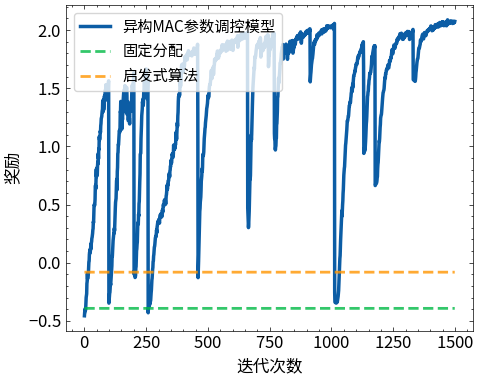

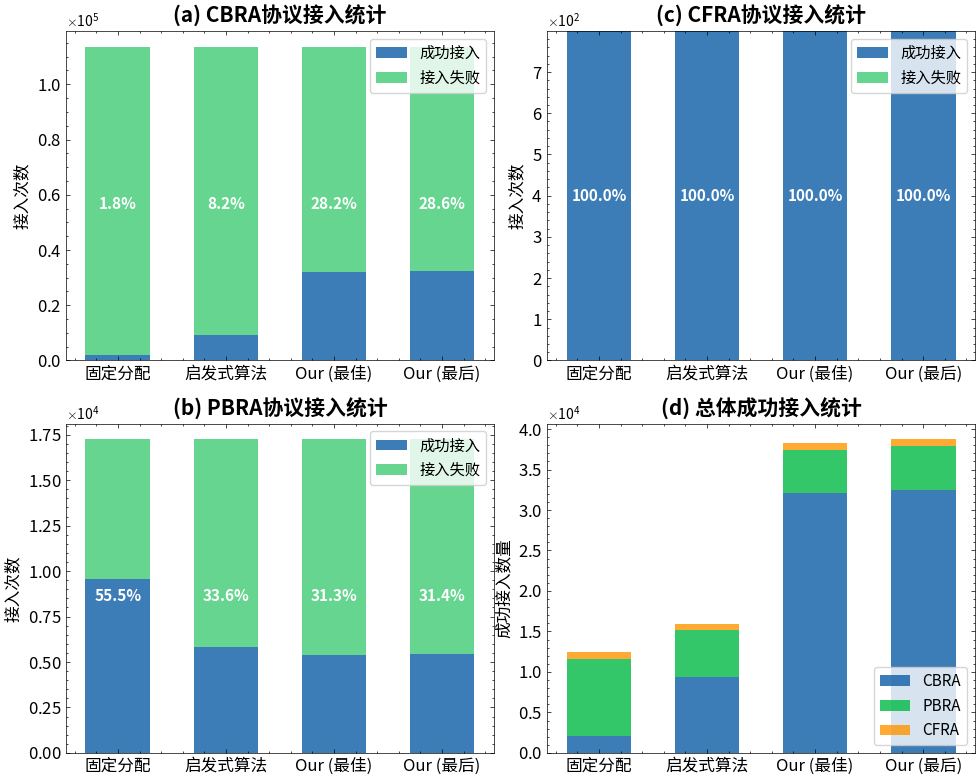

In [ ]:
# 创建2x2布局的综合对比图
if not metrics_history:
    raise RuntimeError("metrics_history is empty; run the training cell first.")

df = pd.DataFrame(metrics_history)
plot_columns = [col for col in ("reward",) if col in df]

if not plot_columns:
    raise RuntimeError("No reward column found in metrics_history.")

# 使用实际的基线数据
fixed_baseline = float(baseline_df[baseline_df["strategy"] == "固定分配"]["avg_reward_per_step"].mean())
heuristic_baseline = float(baseline_df[baseline_df["strategy"] == "启发式算法"]["avg_reward_per_step"].mean())

# 准备协议成功率数据
strategies = ['固定分配', '启发式算法', 'Our (最佳)', 'Our (最后)']
cbra_rates = []
pbra_rates = []
cfra_rates = []

# 固定分配
if '固定分配' in baseline_stats:
    cbra_rates.append(baseline_stats['固定分配']['rate_cbra'])
    pbra_rates.append(baseline_stats['固定分配']['rate_pbra'])
    cfra_rates.append(baseline_stats['固定分配']['rate_cfra'])

# 启发式算法
if '启发式算法' in baseline_stats:
    cbra_rates.append(baseline_stats['启发式算法']['rate_cbra'])
    pbra_rates.append(baseline_stats['启发式算法']['rate_pbra'])
    cfra_rates.append(baseline_stats['启发式算法']['rate_cfra'])

# PPO最佳模型
if 'best_model' in eval_results:
    cbra_rates.append(eval_results['best_model']['eval_rate_cbra'] * 100)
    pbra_rates.append(eval_results['best_model']['eval_rate_pbra'] * 100)
    cfra_rates.append(eval_results['best_model']['eval_rate_cfra'] * 100)

# PPO最后一轮模型
if 'last_model' in eval_results:
    cbra_rates.append(eval_results['last_model']['eval_rate_cbra'] * 100)
    pbra_rates.append(eval_results['last_model']['eval_rate_pbra'] * 100)
    cfra_rates.append(eval_results['last_model']['eval_rate_cfra'] * 100)

# 准备到达量和成功量数据
cbra_arrivals = []
pbra_arrivals = []
cfra_arrivals = []
cbra_success = []
pbra_success = []
cfra_success = []

# 固定分配
if '固定分配' in baseline_stats:
    cbra_arrivals.append(baseline_stats['固定分配']['arrivals_cbra'])
    pbra_arrivals.append(baseline_stats['固定分配']['arrivals_pbra'])
    cfra_arrivals.append(baseline_stats['固定分配']['arrivals_cfra'])
    cbra_success.append(baseline_stats['固定分配']['success_cbra'])
    pbra_success.append(baseline_stats['固定分配']['success_pbra'])
    cfra_success.append(baseline_stats['固定分配']['success_cfra'])

# 启发式算法
if '启发式算法' in baseline_stats:
    cbra_arrivals.append(baseline_stats['启发式算法']['arrivals_cbra'])
    pbra_arrivals.append(baseline_stats['启发式算法']['arrivals_pbra'])
    cfra_arrivals.append(baseline_stats['启发式算法']['arrivals_cfra'])
    cbra_success.append(baseline_stats['启发式算法']['success_cbra'])
    pbra_success.append(baseline_stats['启发式算法']['success_pbra'])
    cfra_success.append(baseline_stats['启发式算法']['success_cfra'])

# PPO最佳模型
if 'best_model' in eval_results:
    cbra_arrivals.append(eval_results['best_model']['eval_arrivals_cbra'])
    pbra_arrivals.append(eval_results['best_model']['eval_arrivals_pbra'])
    cfra_arrivals.append(eval_results['best_model']['eval_arrivals_cfra'])
    cbra_success.append(eval_results['best_model']['eval_success_cbra'])
    pbra_success.append(eval_results['best_model']['eval_success_pbra'])
    cfra_success.append(eval_results['best_model']['eval_success_cfra'])

# PPO最后一轮模型
if 'last_model' in eval_results:
    cbra_arrivals.append(eval_results['last_model']['eval_arrivals_cbra'])
    pbra_arrivals.append(eval_results['last_model']['eval_arrivals_pbra'])
    cfra_arrivals.append(eval_results['last_model']['eval_arrivals_cfra'])
    cbra_success.append(eval_results['last_model']['eval_success_cbra'])
    pbra_success.append(eval_results['last_model']['eval_success_pbra'])
    cfra_success.append(eval_results['last_model']['eval_success_cfra'])

# 第一个图：训练曲线(独立)
fig1, ax_train = plt.subplots(1, 1, figsize=(5, 4))
for column in plot_columns:
    ax_train.plot(df["iteration"], df[column], label="异构MAC参数调控模型", linewidth=2.5)
ax_train.plot(df["iteration"], fixed_baseline * np.ones_like(df["iteration"]), '--',
              label='固定分配', linewidth=2, alpha=0.8)
ax_train.plot(df["iteration"], heuristic_baseline * np.ones_like(df["iteration"]), '--',
              label='启发式算法', linewidth=2, alpha=0.8)
ax_train.set_xlabel("迭代次数", fontsize=12)
ax_train.set_ylabel("奖励", fontsize=12)
ax_train.tick_params(labelsize=12)
ax_train.legend(loc=2, frameon=True, fontsize=11)
plt.tight_layout()
os.makedirs("output/dynamic", exist_ok=True)

plt.savefig("output/dynamic/training_curve.svg", bbox_inches='tight', dpi=300)

# 第二个图：2x2协议统计对比
fig2, axes = plt.subplots(2, 2, figsize=(10, 8))

# 左上：CBRA协议 - 堆叠柱状图显示到达量和成功量
ax_cbra = axes[0, 0]
x = np.arange(len(strategies))
width = 0.6
bars_success = ax_cbra.bar(x, cbra_success, width, label='成功接入', alpha=0.8)
bars_fail = ax_cbra.bar(x, [a - s for a, s in zip(cbra_arrivals, cbra_success)], width,
                        bottom=cbra_success, label='接入失败', alpha=0.6)
ax_cbra.set_ylabel('接入次数', fontsize=12)
ax_cbra.set_title('(a) CBRA协议接入统计', fontsize=15, fontweight='bold')
ax_cbra.set_xticks(x)
ax_cbra.set_xticklabels(strategies, fontsize=11)
ax_cbra.tick_params(labelsize=12)
ax_cbra.ticklabel_format(style='scientific', axis='y', scilimits=(0,0))
ax_cbra.legend(loc='upper right', fontsize=11, frameon=True)
# 在成功接入柱子上显示成功率百分比
for i, (arr, rate) in enumerate(zip(cbra_arrivals, cbra_rates)):
    ax_cbra.text(i, arr / 2, f'{rate:.1f}%',
                ha='center', va='center', fontsize=11, fontweight='bold', color='white')

# 左下：PBRA协议 - 堆叠柱状图
ax_pbra = axes[1, 0]
bars_success = ax_pbra.bar(x, pbra_success, width, label='成功接入', alpha=0.8)
bars_fail = ax_pbra.bar(x, [a - s for a, s in zip(pbra_arrivals, pbra_success)], width,
                        bottom=pbra_success, label='接入失败', alpha=0.6)
ax_pbra.set_ylabel('接入次数', fontsize=12)
ax_pbra.set_title('(b) PBRA协议接入统计', fontsize=15, fontweight='bold')
ax_pbra.set_xticks(x)
ax_pbra.set_xticklabels(strategies, fontsize=11)
ax_pbra.tick_params(labelsize=12)
ax_pbra.ticklabel_format(style='scientific', axis='y', scilimits=(0,0))
ax_pbra.legend(loc='upper right', fontsize=11, frameon=True)
# 在成功接入柱子上显示成功率百分比
for i, (arr, rate) in enumerate(zip(pbra_arrivals, pbra_rates)):
    ax_pbra.text(i, arr / 2, f'{rate:.1f}%',
                ha='center', va='center', fontsize=11, fontweight='bold', color='white')

# 右上：CFRA协议 - 堆叠柱状图
ax_cfra = axes[0, 1]
bars_success = ax_cfra.bar(x, cfra_success, width, label='成功接入', alpha=0.8)
bars_fail = ax_cfra.bar(x, [a - s for a, s in zip(cfra_arrivals, cfra_success)], width,
                        bottom=cfra_success, label='接入失败', alpha=0.6)
ax_cfra.set_ylabel('接入次数', fontsize=12)
ax_cfra.set_title('(c) CFRA协议接入统计', fontsize=15, fontweight='bold')
ax_cfra.set_xticks(x)
ax_cfra.set_xticklabels(strategies, fontsize=11)
ax_cfra.tick_params(labelsize=12)
ax_cfra.ticklabel_format(style='scientific', axis='y', scilimits=(0,0))
ax_cfra.legend(loc='upper right', fontsize=11, frameon=True)
# 在成功接入柱子上显示成功率百分比
for i, (arr, rate) in enumerate(zip(cfra_arrivals, cfra_rates)):
    ax_cfra.text(i, arr / 2, f'{rate:.1f}%',
                ha='center', va='center', fontsize=11, fontweight='bold', color='white')

# 右下：总体统计 - 显示所有协议的总包数量和占比
ax_total = axes[1, 1]

# 计算总包数量
total_arrivals = [cbra + pbra + cfra for cbra, pbra, cfra in zip(cbra_arrivals, pbra_arrivals, cfra_arrivals)]
total_success = [cbra + pbra + cfra for cbra, pbra, cfra in zip(cbra_success, pbra_success, cfra_success)]

# 绘制堆叠柱状图
bars_cbra_total = ax_total.bar(x, cbra_success, width, label='CBRA', alpha=0.8)
bars_pbra_total = ax_total.bar(x, pbra_success, width, bottom=cbra_success,
                                label='PBRA', alpha=0.8)
bars_cfra_total = ax_total.bar(x, cfra_success, width,
                                bottom=[cb + pb for cb, pb in zip(cbra_success, pbra_success)],
                                label='CFRA', alpha=0.8)

ax_total.set_ylabel('成功接入数量', fontsize=12)
ax_total.set_title('(d) 总体成功接入统计', fontsize=15, fontweight='bold')
ax_total.set_xticks(x)
ax_total.set_xticklabels(strategies, fontsize=11)
ax_total.tick_params(labelsize=12)
ax_total.ticklabel_format(style='scientific', axis='y', scilimits=(0,0))
ax_total.legend(loc='lower right', fontsize=11, frameon=True)

# 在每个策略的柱子中心显示总成功率
# for i, (total_arr, total_succ) in enumerate(zip(total_arrivals, total_success)):
#     total_rate = (total_succ / total_arr * 100) if total_arr > 0 else 0
#     # 将文字放在柱子高度的中心位置
#     ax_total.text(i, total_arr / 2, f'{total_rate:.1f}%',
#                 ha='center', va='center', fontsize=11, fontweight='bold', color='white')

plt.tight_layout()
plt.savefig("output/dynamic/protocol_comparison.svg", bbox_inches='tight')

# 打印统计信息
print(f"\n{'='*80}")
print("综合性能对比统计")
print(f"{'='*80}")
print("\n训练性能:")
print(f"  固定分配基线: {fixed_baseline:.4f}")
print(f"  启发式算法基线: {heuristic_baseline:.4f}")
print(f"  PPO最终性能: {df['reward'].iloc[-1]:.4f}")
print(f"  相对于固定分配的提升: {(df['reward'].iloc[-1] / fixed_baseline - 1) * 100:.2f}%")
print(f"  相对于启发式的提升: {(df['reward'].iloc[-1] / heuristic_baseline - 1) * 100:.2f}%")
print("\n协议接入统计对比:")
print(f"{'策略':<15} {'协议':<8} {'到达量':>10} {'成功量':>10} {'成功率':>10}")
print("-"*80)
for i, strategy in enumerate(strategies):
    print(f"{strategy:<15} {'CBRA':<8} {int(cbra_arrivals[i]):>10} {int(cbra_success[i]):>10} {cbra_rates[i]:>9.2f}%")
    print(f"{'':15} {'PBRA':<8} {int(pbra_arrivals[i]):>10} {int(pbra_success[i]):>10} {pbra_rates[i]:>9.2f}%")
    print(f"{'':15} {'CFRA':<8} {int(cfra_arrivals[i]):>10} {int(cfra_success[i]):>10} {cfra_rates[i]:>9.2f}%")
    if i < len(strategies) - 1:
        print("-"*80)
print(f"{'='*80}")
